In [ ]:
from sklearn.datasets import load_iris
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
iris = load_iris()
bc_data = load_breast_cancer()

X = pd.DataFrame(iris.data, columns=iris.feature_names)

# create temp_df to hold a 1-d array of 
temp_df = pd.Categorical.from_codes(iris.target, iris.target_names)

# take the temp_df and convert it to the full target df with a column for each iris type encoded 1 or 0
y = pd.get_dummies(temp_df,prefix=None, prefix_sep=None,dtype=int )


In [9]:
# View the features and target variable
print(X.head())
print (len(X))
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
150
   setosa  versicolor  virginica
0       1           0          0
1       1           0          0
2       1           0          0
3       1           0          0
4       1           0          0


In [8]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
random_state=20260310, stratify=y)


#instantiate the model
knn = KNeighborsClassifier(n_neighbors=6)
#fit the model to the training dataset
knn.fit(X_train, y_train)
# this code performance scores the model against the test data and prints the result as “accuracy”
print(knn.score(X_test, y_test))

# predict the target values as y_pred
y_pred = knn.predict(X_test)

# print the classification report comparing actual target against predicted target
print(classification_report(y_test, y_pred) ) # prints 



0.868421052631579
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.91      0.77      0.83        13
           2       0.77      0.83      0.80        12

   micro avg       0.89      0.87      0.88        38
   macro avg       0.89      0.87      0.88        38
weighted avg       0.90      0.87      0.88        38
 samples avg       0.87      0.87      0.87        38



c:\Users\tombe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


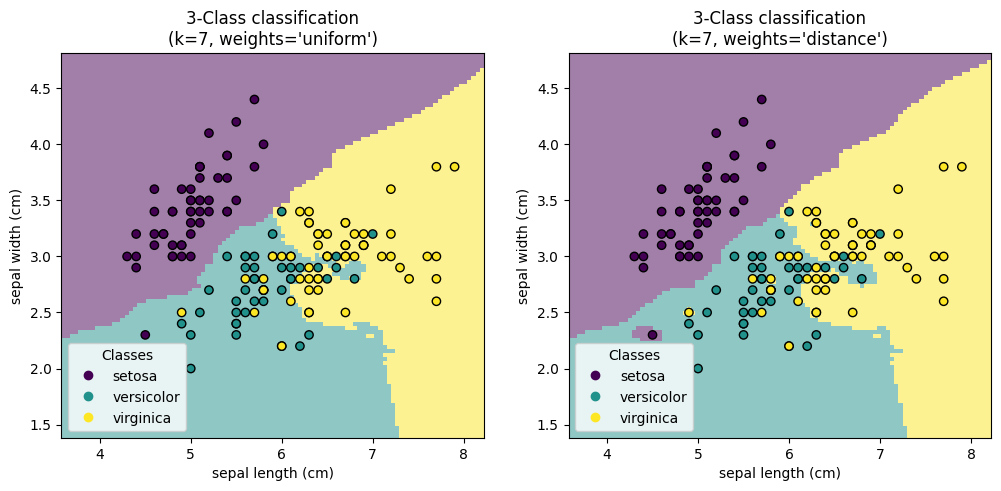

In [17]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
X = iris.data[["sepal length (cm)", "sepal width (cm)"]]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)


from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))]
)

import matplotlib.pyplot as plt

from sklearn.inspection import DecisionBoundaryDisplay

_, axs = plt.subplots(ncols=2, figsize=(12, 5))

for ax, weights in zip(axs, ("uniform", "distance")):
    clf.set_params(knn__weights=weights).fit(X_train, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
        shading="auto",
        alpha=0.5,
        ax=ax,
    )
    scatter = disp.ax_.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        iris.target_names,
        loc="lower left",
        title="Classes",
    )
    _ = disp.ax_.set_title(
        f"3-Class classification\n(k={clf[-1].n_neighbors}, weights={weights!r})"
    )

plt.show()